In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
from scipy.interpolate import pchip_interpolate

In [ ]:
# 1. Исходные данные 
years = np.array([2021, 2022, 2023, 2024, 2025])
headcount = np.array([60643, 55048, 55834, 69915, 83567]) 

# 2. Создаем временную шкалу для 20 кварталов
quarters = np.linspace(2021, 2025, 20)

# 3. Применяем PCHIP интерполяцию
pchip = PchipInterpolator(years, headcount)
headcount_quarters = pchip(quarters)

# 4. Формируем DataFrame
df = pd.DataFrame({
    'Quarter': pd.date_range(start='2021-01-01', periods=20, freq='Q'),
    'Interpolated_Headcount': headcount_quarters
})
df

# Весовая интерполяция по финансовым показателям (Pro-уровень)

In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate
import matplotlib.pyplot as plt

In [3]:
# 1. Исходные данные
years = [2021, 2022, 2023, 2024, 2025]
annual_headcount = np.array([60643, 55048, 55834, 69915, 83567])

# расходы на персонал  за 20 кварталов
quarterly_expenses = np.array([
    40.9, 42, 62.5, 71.7,  # 2021 
    52, 46.65, 51.65, 65,  # 2022 
    50.7, 54.1, 58.8, 60,  # 2023 
    50, 54.5, 57, 73.6,  # 2024 
    60, 63, 65.3, 75.4   # 2025 
])

# 2. Расчет квартальных весов внутри каждого года
def get_weights(expenses):
    # Группируем по 4 и делим каждый квартал на сумму за год
    reshaped = expenses.reshape(-1, 4)
    annual_sums = reshaped.sum(axis=1).reshape(-1, 1)
    weights = reshaped / annual_sums
    return weights.flatten()

weights = get_weights(quarterly_expenses)

# 3. Распределение годовой численности по весам
# Мы считаем, что годовое значение — это среднее за 4 квартала
q_headcount_raw = []
for i, annual_val in enumerate(annual_headcount):
    # Каждое квартальное значение = (Годовое значение) * (Вес квартала * 4)
    # Умножаем на 4, чтобы среднее по кварталам совпало с годовым
    q_values = annual_val * (weights[i*4 : (i+1)*4] * 4)
    q_headcount_raw.extend(q_values)

# 4. Сглаживание (опционально)
# Чтобы убрать резкие скачки между 4-м кварталом прошлого года и 1-м текущего
x_old = np.arange(len(q_headcount_raw))
x_new = np.linspace(0, len(q_headcount_raw) - 1, len(q_headcount_raw))
q_headcount_smooth = pchip_interpolate(x_old, q_headcount_raw, x_new)

# 5. Сборка 
df = pd.DataFrame({
    'Quarter': pd.date_range(start='2021-01-01', periods=20, freq='QE'),
    'Financial_Proxy': quarterly_expenses,
    'Weighted_Headcount': q_headcount_smooth
})
df['Weighted_Headcount']=df['Weighted_Headcount'].round(2)
df

,Quarter,Financial_Proxy,Weighted_Headcount
0,2021-03-31,40.90,45698.73
1,2021-06-30,42.00,46927.79
2,2021-09-30,62.50,69833.03
3,2021-12-31,71.70,80112.45
4,2022-03-31,52.00,53181.53
5,2022-06-30,46.65,47709.97
6,2022-09-30,51.65,52823.58
7,2022-12-31,65.00,66476.92
8,2023-03-31,50.70,50640.14
9,2023-06-30,54.10,54036.13


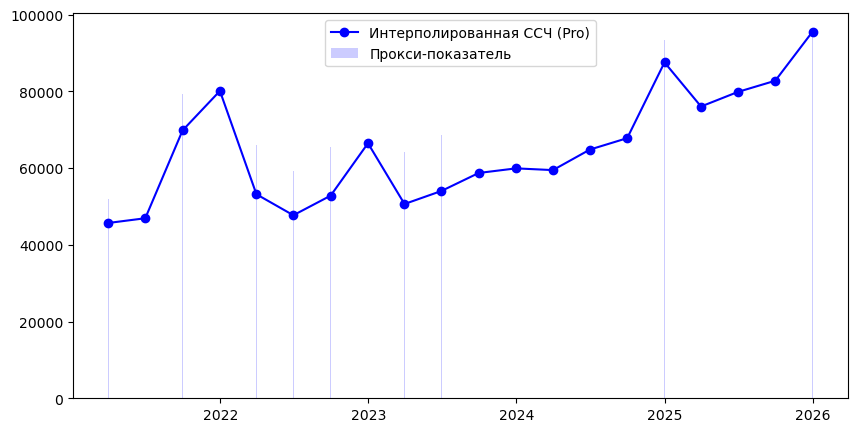

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(df['Quarter'], df['Weighted_Headcount'], label='Интерполированная ССЧ (Pro)', color='blue', marker='o')
plt.bar(df['Quarter'], df['Financial_Proxy'] * (df['Weighted_Headcount'].max()/df['Financial_Proxy'].max()), 
        alpha=0.2, label='Прокси-показатель', color='blue') # МАСШТАБИРОВАН
plt.legend()
#plt.title('Результат весовой интерполяции численности персонала')


#plt.savefig('Результат весовой интерполяции численности персонала.png',dpi=600)
plt.show()

# LinearRegression

In [5]:
from sklearn import tree
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score
#from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
%matplotlib inline

In [6]:
data=pd.DataFrame({'Assets':[19083.04, 19083.04, 19083.04, 19083.04, 20631.98, 20631.98, 20631.98, 20631.98, 
                             25770.55, 25770.55, 25770.55, 25770.55, 33033.19, 33033.19, 33033.19, 33033.19, 
                             32612.75, 32821.88, 32699.26, 33501.6], # активы (млрд. руб.)
                   'Net_interest_margin':[3.7, 3.8, 3.9, 3.7, 3.1, 1.8, 3.1, 1.8, 3.1, 3.3, 3.1, 2.9, 2.2, 1.9,
                                         1.8, 1.7, 0.7, 0.9, 1.5, 1.4], # NIM читсая процентная маржа (%)
                   'Net_commission_income':[38.6, 39, 39.1, 31.2, 39, 55.7, 7, 15.7, 30.48, 37.55, 43.1, 36.5,
                                           35.06, 33.9, 66.06, 75.91, 60.05, 48.94, 72.08, 80.15], # чистый комиссионный доход (млрд. руб.)
                   'Operating_income':[150, 141.6, 141.8, 152.7, 150, 120, 40.91, 68, 157.36, 173.35, 
                                       186.96, 89.79, 130.19, 107.37, 147.77,  129.2, 63.9, 130.63,
                                      152.22, 211.01], # операционный доход (млрд. руб.)
                   'IT_expenses':[11.8, 12.1, 11.1, 15.4, 20, 15, 25, 30, 14.2, 14.2, 15.8, 20.6, 18.5,
                                 24.1, 20.9, 116.5, 18.5, 10.4, 12.5, 23.4], # расходы на IT (млрд. руб.)
                   #'Employee_costs':[40.9, 42, 62.5, 71.7, 52, 45.65, 51.65, 65, 50.7, 54.1, 58.8, 60,
                                  #  50, 54.5, 57, 73.6, 60, 63, 65.3, 75.4], # расходы на персонал (млрд. руб.)
                   'Number_of_offices':[1400, 1400, 1403, 1390, 1378, 1368, 1365, 1368, 1368, 1368, 1368, 1375,
                                        1375, 1550, 1550, 1600, 1638, 1638, 1793, 1843]}) #количество офисов                                   

data['Weighted_Headcount']=df['Weighted_Headcount']
data['Quarter']=df['Quarter']
data['Efficiency']=data['Operating_income']*1000000000/data['Weighted_Headcount'] #  в руб./чел.
data

,Assets,Net_interest_margin,Net_commission_income,Operating_income,IT_expenses,Number_of_offices,Weighted_Headcount,Quarter,Efficiency
0,19083.04,3.7,38.60,150.00,11.8,1400,45698.73,2021-03-31,3.282367e+06
1,19083.04,3.8,39.00,141.60,12.1,1400,46927.79,2021-06-30,3.017402e+06
2,19083.04,3.9,39.10,141.80,11.1,1403,69833.03,2021-09-30,2.030558e+06
3,19083.04,3.7,31.20,152.70,15.4,1390,80112.45,2021-12-31,1.906071e+06
4,20631.98,3.1,39.00,150.00,20.0,1378,53181.53,2022-03-31,2.820528e+06
5,20631.98,1.8,55.70,120.00,15.0,1368,47709.97,2022-06-30,2.515198e+06
6,20631.98,3.1,7.00,40.91,25.0,1365,52823.58,2022-09-30,7.744647e+05
7,20631.98,1.8,15.70,68.00,30.0,1368,66476.92,2022-12-31,1.022911e+06
8,25770.55,3.1,30.48,157.36,14.2,1368,50640.14,2023-03-31,3.107416e+06
9,25770.55,3.3,37.55,173.35,14.2,1368,54036.13,2023-06-30,3.208039e+06


In [ ]:
data.corr()

### МОДЕЛЬ 1
Модель экстенсивного роста. Как масштаб бизнеса диктует наем персонала.

#### используем TimeSeriesSplit

#### Поскольку у вас банковская сфера, в данных могут быть «выбросы» (например, покупка другого банка или резкое сокращение филиалов). StandardScaler чувствителен к ним.

RobustScaler использует медиану и межквартильный размах. Он сделает модель более устойчивой к историческим аномалиям.

### построим модель по приросту, а не по итоговому числу персонала 

In [7]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [8]:
df = data.copy()
df['date'] = pd.to_datetime(df['Quarter'])

# 2. Устанавливаем её как индекс
df = df.set_index('date')

# 3. Теперь это сработает!
df['nQuarter']=np.tile([1, 2, 3, 4], 5)
df['trend'] = np.arange(len(df))

In [9]:
df = df.dropna()

In [10]:
X = df[['Assets', 'Number_of_offices', 'nQuarter', 'trend']]
y =df['Weighted_Headcount']

pipeline_final = Pipeline([
    ('scaler', RobustScaler()),
    #('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Lasso(alpha=100)) # Lasso уберет лишний "шум" от полиномов
])
tscv = TimeSeriesSplit(n_splits=4)
cv_results = cross_val_score(pipeline_final, X, y, cv=tscv, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_results)

print(f"Новые RMSE на фолдах: {rmse_scores}")
print(f"Новый средний RMSE: {rmse_scores.mean():.4f}")
pipeline_final.fit(X, y)

r2 = pipeline_final.score(X, y)
print(f"R^2 модели: {r2:.4f}")

Новые RMSE на фолдах: [11518.83879176  8687.22631232 12789.71832718 10882.33520903]
Новый средний RMSE: 10969.5297
R^2 модели: 0.8070


In [11]:
coeffs = pipeline_final.named_steps['regressor'].coef_
print(dict(zip(X.columns, coeffs)))
intercept = pipeline_final.named_steps['regressor'].intercept_
print(intercept)

{'Assets': np.float64(3933.5673389271574), 'Number_of_offices': np.float64(11406.17290021538), 'nQuarter': np.float64(7893.283524739626), 'trend': np.float64(0.0)}
60033.03216796932


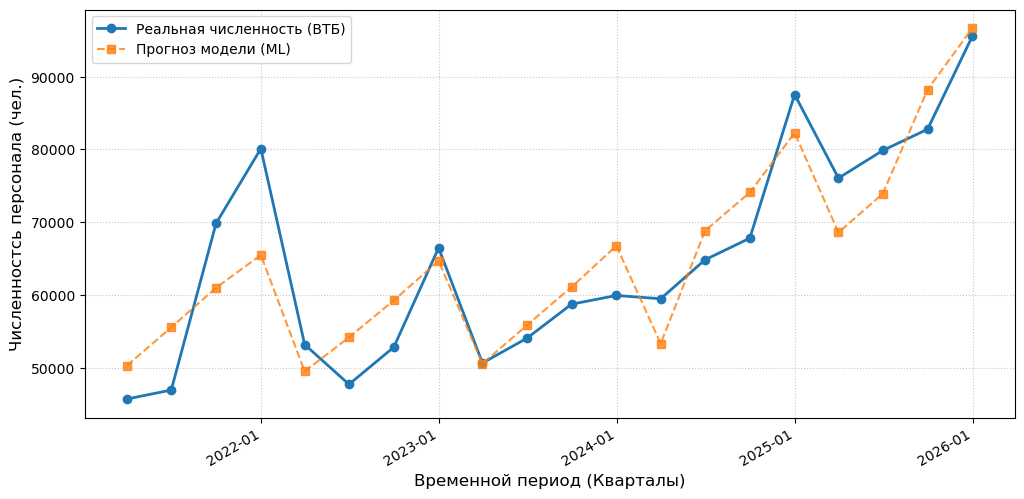

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 1. Получаем предсказания
y_pred = pipeline_final.predict(X)
plt.figure(figsize=(12, 6))
plt.plot(df['Quarter'], y.values, label='Реальная численность (ВТБ)', marker='o', linewidth=2)
plt.plot(df['Quarter'], y_pred, label='Прогноз модели (ML)', linestyle='--', marker='s', alpha=0.8)

# Настройка формата оси X (чтобы отображались кварталы/годы)
ax = plt.gca()
# Устанавливаем формат отображения: '2021-Q1' или '2021-03'
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 
# Автоматически наклоняем даты для читаемости
plt.gcf().autofmt_xdate()

#plt.title('Анализ и прогноз прирост численности персонала Банка ВТБ (ПАО)', fontsize=14)
plt.xlabel('Временной период (Кварталы)', fontsize=12)
plt.ylabel('Численностсь персонала (чел.)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True)
#plt.savefig('Прогноз_ВТБ_ML.png', dpi=1000, bbox_inches='tight')
plt.show()

In [13]:
import statsmodels.api as sm

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_scaled_df = sm.add_constant(X_scaled_df)
model = sm.OLS(y, X_scaled_df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     Weighted_Headcount   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     15.84
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           2.91e-05
Time:                        19:00:21   Log-Likelihood:                -203.16
No. Observations:                  20   AIC:                             416.3
Df Residuals:                      15   BIC:                             421.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              5.974e+04   2279.07

## прогнозируем

In [14]:
# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ ПРОГНОЗА
last_date = df.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=8, freq='QE') # проставили даты для будущих индексов

# Создаем пустой DataFrame для будущего
X_future = pd.DataFrame(index=future_dates)

In [15]:
# Продлеваем тренд (если в истории было 0-19, то тут 20-27)
last_trend_value = df['trend'].max()
X_future['trend'] = np.arange(last_trend_value + 1, last_trend_value + 9)

# Устанавливаем nQuarter (месяцы 3, 6, 9, 12)
X_future['nQuarter'] = X_future.index.quarter

# ГИПОТЕЗА РОСТА 
# Коэффициент среднего квартального роста (3.02%)
growth_rate = 1.0302
office_expansion_q = 40   # органический рост
integration_jump = 150      # скачок от интеграции 

last_assets = df['Assets'].iloc[-1]
last_offices = df['Number_of_offices'].iloc[-1]
# Прогноз активов на 8 кварталов вперед на основе исторического среднего
X_future['Assets'] = [last_assets * (growth_rate ** i) for i in range(1, 9)]

# Фактор офисов: логика "Интеграция в Q2 2026"
offices_list = []
for i in range(1, 8 + 1):
    current_q_date = future_dates[i-1]
    
    # Считаем органический рост
    current_offices = last_offices + (office_expansion_q* i)
    
    # Если наступил Q2 2026 (июнь) или позже — добавляем интеграцию
    if current_q_date >= pd.Timestamp('2026-06-30'):
        current_offices += integration_jump
        
    offices_list.append(current_offices)

X_future['Number_of_offices'] = offices_list

In [16]:
# 2. РАСЧЕТ ПРОГНОЗА
# Используем наш готовый pipeline (он сам применит RobustScaler)
forecast_values = pipeline_final.predict(X_future[['Assets', 'Number_of_offices', 'nQuarter', 'trend']])

# Собираем результат в таблицу
df_forecast = pd.DataFrame({'Forecast': forecast_values}, index=future_dates)

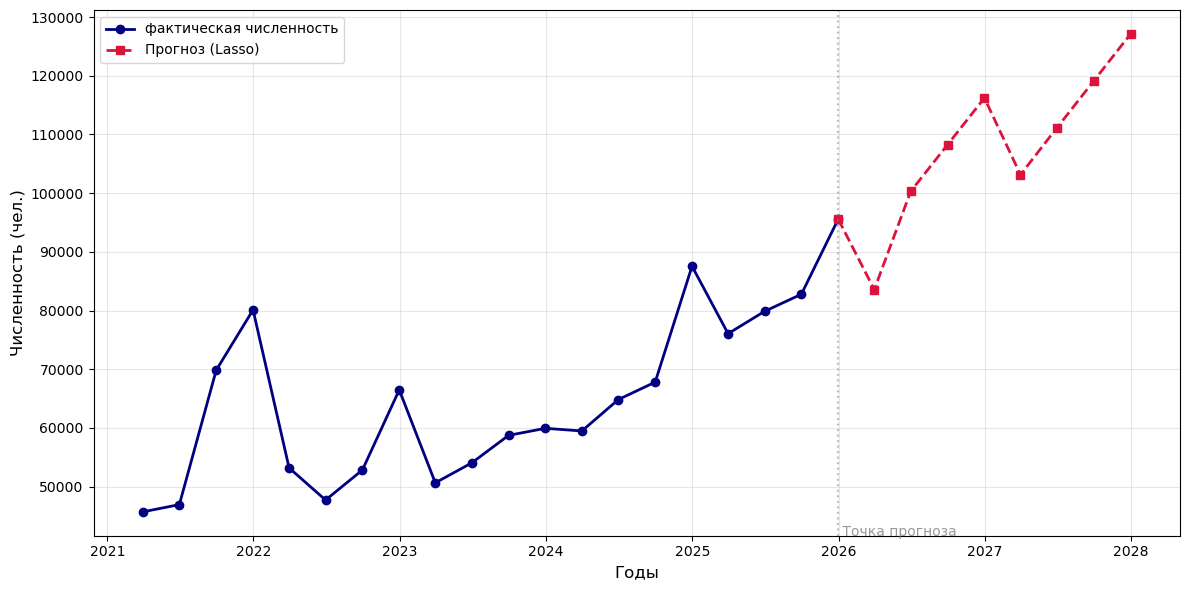

In [17]:
plt.figure(figsize=(12, 6))
# 1. Линия истории
plt.plot(df.index, df['Weighted_Headcount'], label='фактическая численность', marker='o', color='navy', linewidth=2)

# 2. Соединяем историю с прогнозом
# Для этого добавляем последнюю точку истории в начало данных прогноза
conn_index = [df.index[-1]] + list(df_forecast.index)
conn_values = [df['Weighted_Headcount'].iloc[-1]] + list(df_forecast['Forecast'])

# 3. Линия прогноза (теперь она начинается от последней точки факта)
plt.plot(conn_index, conn_values, label='Прогноз (Lasso)', linestyle='--', marker='s', color='crimson', linewidth=2)
#plt.title('Прогноз численности персонала ВТБ (ПАО) ', fontsize=14)
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Численность (чел.)', fontsize=12)

# Добавляем вертикальную линию в точке раздела, чтобы визуально отделить прогноз
plt.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.5)
plt.text(df.index[-1], plt.ylim()[0], ' Точка прогноза', color='gray', alpha=0.8)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('Будущий прогноз 2026-2027 для ML1.png', dpi=1000, bbox_inches='tight')
plt.show()

In [18]:
# Вывод цифр
print("Прогноз численности по кварталам:")
print(df_forecast.round(0))

Прогноз численности по кварталам:
            Forecast
2026-03-31   83567.0
2026-06-30  100306.0
2026-09-30  108259.0
2026-12-31  116222.0
2027-03-31  103148.0
2027-06-30  111133.0
2027-09-30  119130.0
2027-12-31  127138.0


In [19]:
df_forecast.round(0).T

,2026-03-31,2026-06-30,2026-09-30,2026-12-31,2027-03-31,2027-06-30,2027-09-30,2027-12-31
Forecast,83567.0,100306.0,108259.0,116222.0,103148.0,111133.0,119130.0,127138.0


## МОДЕЛЬ 2
Модель деловой активности. Как транзакционная активность клиентов влияет на штат.

In [20]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
df = data.copy()

In [21]:
df['date'] = pd.to_datetime(df['Quarter'])
df = df.set_index('date')
df['lag_1'] = df['Weighted_Headcount'].shift(1)
df['nQuarter'] =df.index.quarter
df['trend'] = np.arange(len(df))

In [22]:
df = df.dropna()

In [24]:
# Используем предикторы, которые мы точно будем знать через 2 года:
X = df[['Assets', 'Net_commission_income', 'nQuarter', 'trend', 'lag_1']]
y =df['Weighted_Headcount']

pipeline_final = Pipeline([
    ('scaler', RobustScaler()),
    #('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Lasso(alpha=100)) # Lasso уберет лишний "шум" от полиномов
])
tscv = TimeSeriesSplit(n_splits=4)
cv_results = cross_val_score(pipeline_final, X, y, cv=tscv, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_results)

print(f"Новые RMSE на фолдах: {rmse_scores}")
print(f"Новый средний RMSE: {rmse_scores.mean():.4f}")
pipeline_final.fit(X, y)

r2 = pipeline_final.score(X, y)
print(f"R^2 модели: {r2:.4f}")

Новые RMSE на фолдах: [27217.07858003  8264.66503841 14513.14807292  7744.20971721]
Новый средний RMSE: 14434.7754
R^2 модели: 0.8160


In [25]:
coeffs = pipeline_final.named_steps['regressor'].coef_
print(dict(zip(X.columns, coeffs)))
intercept = pipeline_final.named_steps['regressor'].intercept_
print(intercept)

{'Assets': np.float64(7550.998955426477), 'Net_commission_income': np.float64(1407.971871568452), 'nQuarter': np.float64(10912.809507454967), 'trend': np.float64(-0.0), 'lag_1': np.float64(10934.287834931894)}
66298.66223752772


In [26]:
import statsmodels.api as sm
from sklearn.preprocessing import RobustScaler

# 2. Масштабируем признаки вручную (statsmodels этого не делает сам)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# 3. Добавляем константу (интерцепт)
# В sklearn она добавляется автоматически, в statsmodels это нужно делать руками
X_scaled_df = sm.add_constant(X_scaled_df)

# 4. Обучаем модель (Lasso в statsmodels называется OLS с регуляризацией, 
# но для summary чаще используют обычный OLS, чтобы увидеть все значимости)
model = sm.OLS(y, X_scaled_df)
results = model.fit()

# Поэтому для отчета обычно смотрят стандартный OLS:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     Weighted_Headcount   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     12.21
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           0.000156
Time:                        19:02:36   Log-Likelihood:                -191.71
No. Observations:                  19   AIC:                             395.4
Df Residuals:                      13   BIC:                             401.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  6.582e+

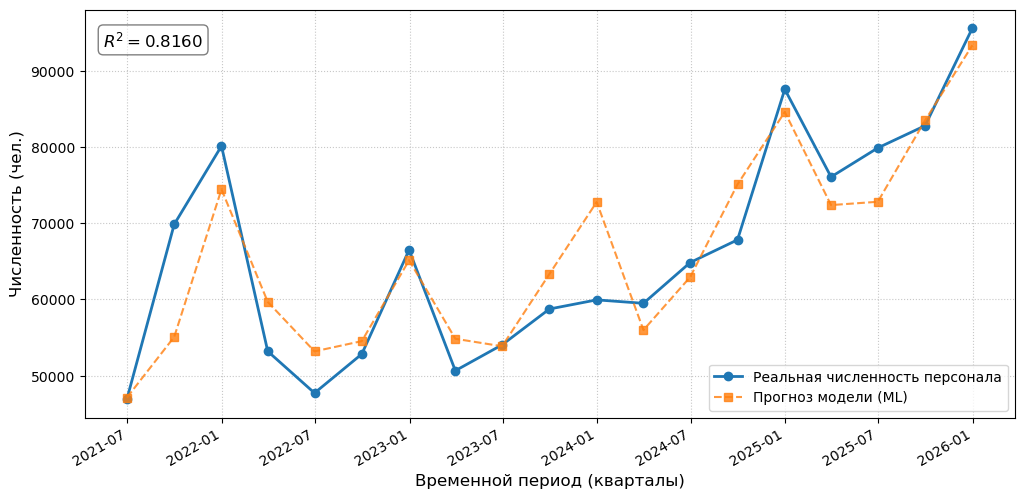

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 1. Получаем предсказания
y_pred = pipeline_final.predict(X)
plt.figure(figsize=(12, 6))
plt.plot(df['Quarter'], y.values, label='Реальная численность персонала', marker='o', linewidth=2)
plt.plot(df['Quarter'], y_pred, label='Прогноз модели (ML)', linestyle='--', marker='s', alpha=0.8)

# Настройка формата оси X (чтобы отображались кварталы/годы)
ax = plt.gca()
# Устанавливаем формат отображения: '2021-Q1' или '2021-03'
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 
# Автоматически наклоняем даты для читаемости
plt.gcf().autofmt_xdate()

#plt.title('Анализ и прогноз прирост численности персонала Банка ВТБ (ПАО)', fontsize=14)
plt.xlabel('Временной период (кварталы)', fontsize=12)
plt.ylabel('Численность (чел.)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True)
#plt.savefig('Прогноз_ВТБ_ML2.png', dpi=1000, bbox_inches='tight')
plt.text(0.02, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.show()

### прогноз

In [30]:
assets_growth = 1.0302
nci_growth = 1.0392 

# 1. Подготовка структуры будущего
future_dates = pd.date_range(start='2026-03-31', periods=8, freq='QE')
X_future = pd.DataFrame(index=future_dates)

last_trend = df['trend'].max()
last_assets = df['Assets'].iloc[-1]
last_nci = df['Net_commission_income'].iloc[-1]
last_headcount = df['Weighted_Headcount'].iloc[-1]

# 2. Заполнение независимых факторов
X_future['trend'] = np.arange(last_trend + 1, last_trend + 9)
X_future['nQuarter'] = X_future.index.quarter
X_future['Assets'] = [last_assets * (assets_growth ** i) for i in range(1, 9)]
X_future['Net_commission_income'] = [last_nci * (nci_growth ** i) for i in range(1, 9)]
feature_names = ['Assets', 'Net_commission_income', 'nQuarter', 'trend', 'lag_1']

forecast_results = []
current_lag = last_headcount

for i in range(len(X_future)):
    # Извлекаем данные для текущего шага
    assets = X_future.iloc[i]['Assets']
    nci = X_future.iloc[i]['Net_commission_income']
    n_quarter = X_future.iloc[i]['nQuarter']
    trend = X_future.iloc[i]['trend']
    
    row_df = pd.DataFrame([[assets, nci, n_quarter, trend, current_lag]], 
                          columns=feature_names)
    
    # Теперь predict сработает без ошибок
    pred = pipeline_final.predict(row_df)[0]
    forecast_results.append(pred)
    
    # Обновляем лаг для следующего квартала
    current_lag = pred

# Добавляем результат в таблицу
X_future['Forecast_Headcount'] = forecast_results

print("Прогноз численности персонала ВТБ (2026-2027):")
print(X_future[['Assets', 'Net_commission_income', 'Forecast_Headcount']].round(0))

Прогноз численности персонала ВТБ (2026-2027):
             Assets  Net_commission_income  Forecast_Headcount
2026-03-31  34513.0                   83.0             79329.0
2026-06-30  35556.0                   87.0             78532.0
2026-09-30  36629.0                   90.0             86233.0
2026-12-31  37736.0                   93.0             98623.0
2027-03-31  38875.0                   97.0             84511.0
2027-06-30  40049.0                  101.0             84999.0
2027-09-30  41259.0                  105.0             93522.0
2027-12-31  42505.0                  109.0            106484.0


In [31]:
X_future[['Forecast_Headcount']].round(0).T

,2026-03-31,2026-06-30,2026-09-30,2026-12-31,2027-03-31,2027-06-30,2027-09-30,2027-12-31
Forecast_Headcount,79329.0,78532.0,86233.0,98623.0,84511.0,84999.0,93522.0,106484.0


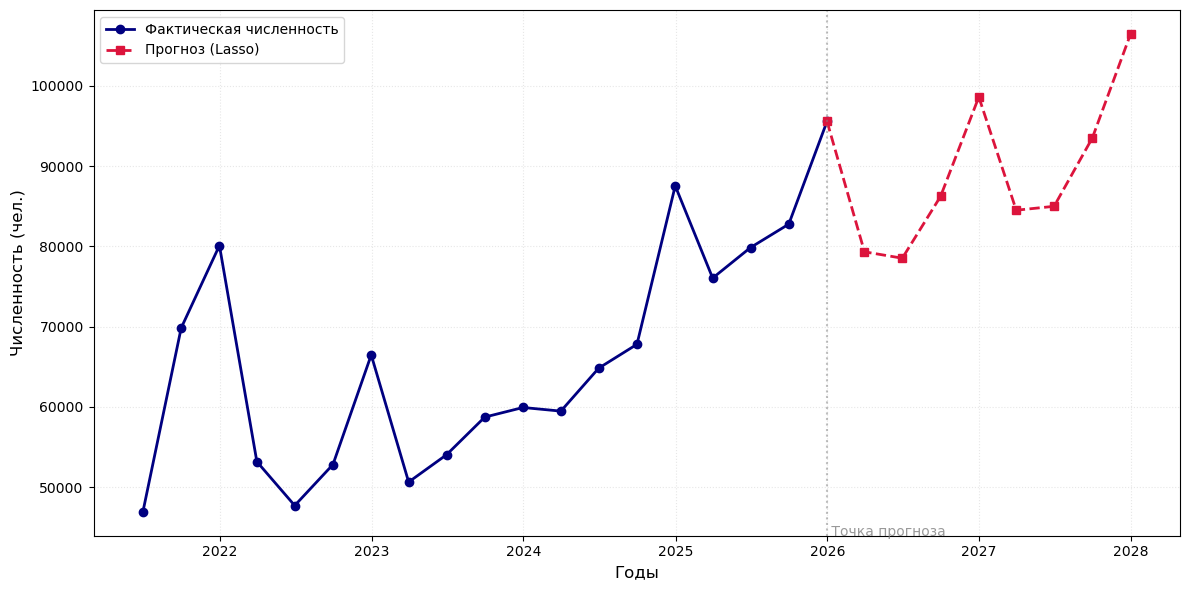

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Weighted_Headcount'], label='Фактическая численность', marker='o', color='navy', linewidth=2)

# 2. Подготовка данных для прогноза (чтобы линии соединились)
# Берем последнюю точку из истории и соединяем с прогнозом
last_date = df.index[-1]
last_val = df['Weighted_Headcount'].iloc[-1]

forecast_dates = [last_date] + list(X_future.index)
forecast_values = [last_val] + list(X_future['Forecast_Headcount'])

# 3. Отрисовка прогноза
plt.plot(forecast_dates, forecast_values, label='Прогноз (Lasso)', linestyle='--', marker='s', color='crimson', linewidth=2)
# plt.title('Прогноз численности персонала ВТБ (ПАО) до 2027 года', fontsize=14)
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Численность (чел.)', fontsize=12)


plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)
# Добавляем вертикальную линию в точке раздела, чтобы визуально отделить прогноз
plt.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.5)
plt.text(df.index[-1], plt.ylim()[0], ' Точка прогноза', color='gray', alpha=0.8)
#plt.savefig('Будущий прогноз 2026-2027 для ML2.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()

## МОДЕЛЬ 3
Модель интенсивного развития. Как технологии и качество маржи повышают отдачу от людей.

In [33]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
df = data.copy()

In [34]:
df['lag_2'] = df['Efficiency'].shift(2)

In [35]:
df = df.dropna()

In [36]:
X = df[['Net_interest_margin', 'IT_expenses', 'lag_2']]
y =df['Efficiency']

pipeline_final = Pipeline([
    ('scaler', RobustScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Lasso(alpha=100)) # Lasso уберет лишний "шум" от полиномов
])
tscv = TimeSeriesSplit(n_splits=4)
cv_results = cross_val_score(pipeline_final, X, y, cv=tscv, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_results)

print(f"Новые RMSE на фолдах: {rmse_scores}")
print(f"Новый средний RMSE: {rmse_scores.mean():.4f}")
pipeline_final.fit(X, y)

r2 = pipeline_final.score(X, y)
print(f"R^2 модели: {r2:.4f}")

/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.411e+09, tolerance: 3.261e+08
  model = cd_fast.enet_coordinate_descent(
/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.105e+09, tolerance: 6.758e+08
  model = cd_fast.enet_coordinate_descent(
/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.165e+10, tolerance: 9.538e+08
  model = cd_fast.enet_coo

Новые RMSE на фолдах: [ 851527.04481787 1181382.30222552 5165547.06755537 1382001.03439778]
Новый средний RMSE: 2145114.3622
R^2 модели: 0.8496


In [37]:
# 1. Получаем список всех 9 названий признаков из шага 'poly'
feature_names = pipeline_final.named_steps['poly'].get_feature_names_out(X.columns)

# 2. Получаем коэффициенты из Lasso
coeffs = pipeline_final.named_steps['regressor'].coef_

# 3. Собираем в словарь и выводим
full_coeffs = dict(zip(feature_names, coeffs))

print("--- Все коэффициенты модели (9 штук) ---")
for name, val in full_coeffs.items():
    print(f"{name}: {val:.4f}")

print(f"\nIntercept: {pipeline_final.named_steps['regressor'].intercept_:.4f}")

--- Все коэффициенты модели (9 штук) ---
Net_interest_margin: 794589.9518
IT_expenses: -1023215.6149
lag_2: -145242.7577
Net_interest_margin^2: -1086609.3137
Net_interest_margin IT_expenses: -298450.3099
Net_interest_margin lag_2: -695831.6339
IT_expenses^2: 55728.4415
IT_expenses lag_2: -693191.9186
lag_2^2: -653869.0524

Intercept: 2738474.1297


In [38]:
import statsmodels.api as sm

# Создаем полиномиальные признаки (как в пайплайне)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_columns = poly.get_feature_names_out(X.columns)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_poly)

X_final = pd.DataFrame(X_scaled, columns=poly_columns, index=X.index)
X_final = sm.add_constant(X_final)

model = sm.OLS(y, X_final)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             Efficiency   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     5.020
Date:                Tue, 14 Jul 2026   Prob (F-statistic):             0.0165
Time:                        19:09:18   Log-Likelihood:                -251.65
No. Observations:                  18   AIC:                             523.3
Df Residuals:                       8   BIC:                             532.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

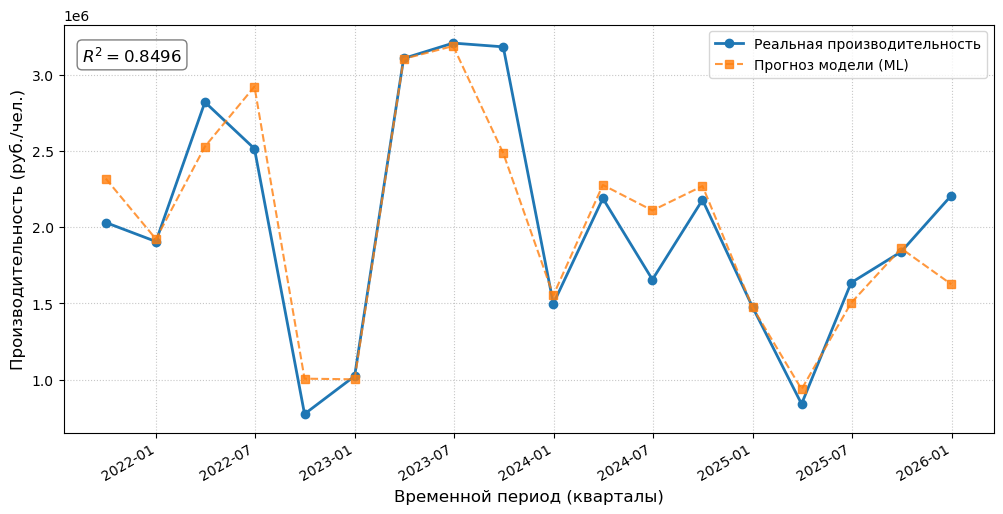

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# 1. Получаем предсказания
y_pred = pipeline_final.predict(X)
plt.figure(figsize=(12, 6))
plt.plot(df['Quarter'], y.values, label='Реальная производительность', marker='o', linewidth=2)
plt.plot(df['Quarter'], y_pred, label='Прогноз модели (ML)', linestyle='--', marker='s', alpha=0.8)

# Настройка формата оси X (чтобы отображались кварталы/годы)
ax = plt.gca()
# Устанавливаем формат отображения: '2021-Q1' или '2021-03'
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 
# Автоматически наклоняем даты для читаемости
plt.gcf().autofmt_xdate()

#plt.title('', fontsize=14)
plt.xlabel('Временной период (кварталы)', fontsize=12)
plt.ylabel('Производительность (руб./чел.)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True)

plt.text(0.02, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

#plt.savefig('Прогноз_ВТБ_ML3.png', dpi=1000, bbox_inches='tight')
plt.show()

### прогноз

In [40]:
# 1. Создаем даты для прогноза (8 кварталов: 2026 и 2027)
future_dates = pd.date_range(start='2026-03-31', periods=8, freq='QE')
X_future = pd.DataFrame(index=future_dates)
#df_forecast['Quarter'] = future_dates
IT_growth=1.0367
n_periods = 8
start_nim = 2.5  # Цель на начало 2026
volatility = 0.15 # Степень "непредсказуемости" рынка
np.random.seed(42)

shocks = np.random.normal(loc=0.02, scale=volatility, size=n_periods) 
shocks[0] = 0

last_IT = df['IT_expenses'].iloc[-1]
last_nim = df['Net_interest_margin'].iloc[-1]
X_future['IT_expenses'] = [last_IT * (IT_growth ** i) for i in range(1, 9)]
# 3. Формируем кумулятивную сумму (каждое значение зависит от предыдущего)
nim_path = start_nim + np.cumsum(shocks)

# 4. Ограничиваем коридором (чтобы не улетело выше 3% или ниже 1.5%)
X_future['Net_interest_margin'] = np.clip(nim_path, 1.5, 3)

# Нам понадобятся исторические данные, чтобы взять lag_2 для первых прогнозов 2026 года
# Допустим, df_last — это последние строки ваших исторических данных

# Создаем копию последних данных для инициализации лагов
history = df[['Net_interest_margin', 'IT_expenses', 'Efficiency']].copy()

predictions = []

for i in range(len(X_future)):
    # 1. Берем текущие значения факторов
    current_nim = X_future.iloc[i]['Net_interest_margin']
    current_it = X_future.iloc[i]['IT_expenses']
    
    # 2. Находим lag_2 (значение Efficiency 2 квартала назад)
    # Если это первые итерации — берем из истории, если нет — из новых предсказаний
    if i == 0:
        lag_val = history.iloc[-2]['Efficiency']
    elif i == 1:
        lag_val = history.iloc[-1]['Efficiency']
    else:
        lag_val = predictions[i-2]
    
    # 3. Формируем вектор X для модели
    X_step = pd.DataFrame([[current_nim, current_it, lag_val]], 
                         columns=['Net_interest_margin', 'IT_expenses', 'lag_2'])
    
    # 4. Делаем предсказание
    y_step = pipeline_final.predict(X_step)[0]
    predictions.append(y_step)

# Добавляем результаты в таблицу прогноза
X_future['Efficiency_Pred'] = predictions
X_future[['Efficiency_Pred']].T

,2026-03-31,2026-06-30,2026-09-30,2026-12-31,2027-03-31,2027-06-30,2027-09-30,2027-12-31
Efficiency_Pred,2.272728e+06,1.958030e+06,1.758052e+06,1.785884e+06,1.829668e+06,1.705434e+06,1.451249e+06,1.446609e+06


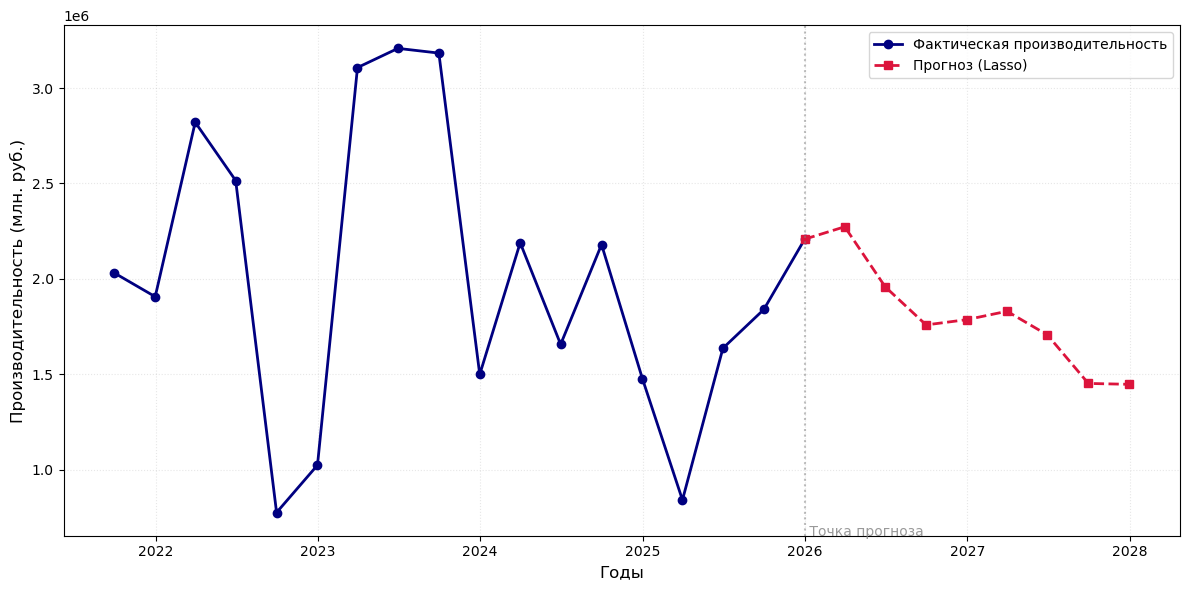

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(df['Quarter'], df['Efficiency'], label='Фактическая производительность', marker='o', color='navy', linewidth=2)

# 2. Подготовка данных для прогноза (чтобы линии соединились)
# Берем последнюю точку из истории и соединяем с прогнозом
last_date = df['Quarter'].iloc[-1]
last_val = df['Efficiency'].iloc[-1]

forecast_dates = [last_date] + list(X_future.index)
forecast_values = [last_val] + list(X_future['Efficiency_Pred'])

# 3. Отрисовка прогноза
plt.plot(forecast_dates, forecast_values, label='Прогноз (Lasso)', linestyle='--', marker='s', color='crimson', linewidth=2)
# plt.title('Прогноз численности персонала ВТБ (ПАО) до 2027 года', fontsize=14)
plt.xlabel('Годы', fontsize=12)
plt.ylabel('Производительность (млн. руб.)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)
# Добавляем вертикальную линию в точке раздела, чтобы визуально отделить прогноз
plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.5)
plt.text(last_date, plt.ylim()[0], ' Точка прогноза', color='gray', alpha=0.8)
# plt.savefig('Будущий прогноз 2026-2027 для ML3.png', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()